# 🧠 Fusion Engine — Biometric Stress & Trauma Clustering
## Décision collective sans re-run des notebooks sources

**Meilleurs modèles sélectionnés :**
| Source | Modèle retenu | Rôle |
|--------|--------------|------|
| NB1 WESAD | Stacking (RF+XGB+SVM) + CalibratedClassifier | Stress biométrique HRV/EDA |
| NB2 HRV Clustering | KMeans (k=5, silhouette optimal) | Cluster clinique trauma |
| NB3 trauma-1 | ResNet-18 multi-task (best val trauma acc) | Vision émotion + trauma |
| NB4 Fine-tuning | EfficientNet-B2 multi-task fine-tuné | Vision haute précision |

> **Important** : Ce notebook charge les `.pkl` / `.pt` sauvegardés par chaque notebook.
> Il ne re-entraîne rien. Adapter `MODEL_DIR` à votre chemin `/kaggle/working`.


## Cellule 1 — Installation des dépendances

In [1]:
import sys, subprocess
for pkg in ['neurokit2','xgboost','ultralytics','albumentations']:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('✅ dépendances OK')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00
✅ dépendances OK


## Cellule 2 — Imports & Configuration

In [2]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
from collections import deque
warnings.filterwarnings('ignore')

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

# ── Chemins (adapter si nécessaire) ──────────────────────────────────────────
MODEL_DIR = '/kaggle/working'   # répertoire où NB1/NB2/NB3/NB4 ont sauvegardé leurs fichiers

# ── Constantes partagées ──────────────────────────────────────────────────────
EMOTION_TO_STRESS = {
    'anger':9.0,'contempt':6.5,'disgust':6.0,'fear':8.5,'happiness':1.5,
    'neutral':2.0,'sadness':5.5,'surprise':4.5,
    'angry':9.0,'fearful':8.5,'happy':1.5,'calm':1.5,'sad':5.5,'surprised':4.5,
}
TRAUMA_LABELS   = ['Low','Moderate','High','Crisis']
EMOTION_NAMES   = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
TRAUMA_NAMES_NB3= ['minimal','low','moderate','high/crisis']

NB2_CLUSTER_LABELS = {
    0:'✅ Healthy / Normal',
    1:'⚠️  Mild Stress / Anxiety',
    2:'🔴 Chronic Stress / Burnout',
    3:'🧠 PTSD / Depression Risk',
    4:'🚨 High Clinical Risk',
}

# Poids de fusion (biométrique > vision fine-tuned > vision scratch)
WEIGHTS = {'nb1': 0.45, 'nb4': 0.35, 'nb3': 0.20}

# Seuils décision finale
THRESHOLDS = {'Low':(0,.30),'Moderate':(.30,.55),'High':(.55,.75),'Crisis':(.75,1.01)}

DARK='#0f1117'; SURF='#1a1d2e'
plt.rcParams.update({
    'figure.facecolor':DARK,'axes.facecolor':SURF,'axes.edgecolor':'#3a3f5c',
    'axes.labelcolor':'#e0e0e0','xtick.color':'#b0b0b0','ytick.color':'#b0b0b0',
    'text.color':'#e0e0e0','grid.color':'#2a2f4a','grid.alpha':0.5,
    'legend.facecolor':SURF,'legend.edgecolor':'#3a3f5c',
})
print('✅ configuration OK')
print(f'MODEL_DIR = {MODEL_DIR}')


Device : cuda
✅ configuration OK
MODEL_DIR = /kaggle/working


## Cellule 3 — Chargement du modèle NB1 (WESAD Stacking + Scaler)

In [3]:
# NB1 sauvegarde ces fichiers dans M13 :
#   stacking_clf.pkl   (CalibratedClassifierCV du stacking RF+XGB+SVM)
#   feature_scaler.pkl (RobustScaler ou StandardScaler des features HRV)
#   danger_regressor.pkl (Ridge/XGB pour le score continu 0-100)

NB1_STACK_PATH  = os.path.join(MODEL_DIR, 'stacking_clf.pkl')
NB1_SCALER_PATH = os.path.join(MODEL_DIR, 'feature_scaler.pkl')
NB1_REG_PATH    = os.path.join(MODEL_DIR, 'danger_regressor.pkl')

nb1_stack, nb1_scaler, nb1_reg = None, None, None

if os.path.exists(NB1_STACK_PATH):
    nb1_stack  = joblib.load(NB1_STACK_PATH)
    nb1_scaler = joblib.load(NB1_SCALER_PATH)
    print(f'✅ NB1 stacking chargé  : {NB1_STACK_PATH}')
else:
    print(f'⚠️  NB1 stacking non trouvé — vérifier MODEL_DIR')
    print(f'   Chemin attendu : {NB1_STACK_PATH}')

if os.path.exists(NB1_REG_PATH):
    nb1_reg = joblib.load(NB1_REG_PATH)
    print(f'✅ NB1 régresseur chargé : {NB1_REG_PATH}')

# ── HRV feature extraction (copié de NB1 M2) ─────────────────────────────────
from scipy.signal import find_peaks, butter, filtfilt

def extract_hrv_features(rr_ms: np.ndarray) -> dict:
    """Extrait les features HRV depuis une séquence d'intervalles RR (ms)."""
    rr = rr_ms[~np.isnan(rr_ms)]
    rr = rr[(rr > 300) & (rr < 2000)]
    if len(rr) < 10:
        return {}

    diff_rr = np.diff(rr)
    hr      = 60000.0 / rr

    features = {
        # Time domain
        'Mean_RR'  : np.mean(rr),
        'SDNN'     : np.std(rr),
        'RMSSD'    : np.sqrt(np.mean(diff_rr**2)),
        'pNN50'    : np.sum(np.abs(diff_rr) > 50) / len(diff_rr) * 100,
        'CV_RR'    : np.std(rr) / np.mean(rr),
        'Mean_HR'  : np.mean(hr),
        'HR_std'   : np.std(hr),
        'Min_HR'   : np.min(hr),
        'Max_HR'   : np.max(hr),
        # Poincaré
        'SD1'      : np.std(diff_rr) / np.sqrt(2),
        'SD2'      : np.sqrt(2*np.std(rr)**2 - 0.5*np.std(diff_rr)**2),
        # Entropy proxy
        'SampEn_proxy': float(np.std(diff_rr) / (np.mean(rr) + 1e-9)),
    }

    # Frequency domain (Welch)
    try:
        rr_interp = np.interp(
            np.linspace(0, len(rr), len(rr)*4),
            np.arange(len(rr)), rr
        )
        f, psd = __import__('scipy.signal',fromlist=['welch']).welch(rr_interp, fs=4.0, nperseg=min(256,len(rr_interp)))
        vlf = np.trapz(psd[(f>=0.003)&(f<0.04)], f[(f>=0.003)&(f<0.04)])
        lf  = np.trapz(psd[(f>=0.04) &(f<0.15)], f[(f>=0.04) &(f<0.15)])
        hf  = np.trapz(psd[(f>=0.15) &(f<0.40)], f[(f>=0.15) &(f<0.40)])
        features.update({
            'VLF_power': vlf, 'LF_power': lf, 'HF_power': hf,
            'LF_HF': lf / (hf + 1e-9), 'LF_norm': lf / (lf + hf + 1e-9),
        })
    except Exception:
        features.update({'VLF_power':0,'LF_power':0,'HF_power':0,'LF_HF':3.0,'LF_norm':0.5})

    return features


def predict_nb1(rr_ms: np.ndarray) -> dict:
    """
    Prédit le stress biométrique depuis une séquence RR (ms).
    Retourne dict avec stress_class, stress_proba, danger_score.
    """
    feats = extract_hrv_features(rr_ms)
    if not feats or nb1_stack is None:
        return {'stress_class':1,'stress_proba':[.33,.34,.33],'danger_score':50.0,
                'confidence':0.0,'available':False}

    feat_cols = sorted(feats.keys())
    X = np.array([feats.get(c,0.0) for c in feat_cols]).reshape(1,-1)
    X_s = nb1_scaler.transform(X) if nb1_stack is not None else X

    proba = nb1_stack.predict_proba(X_s)[0]
    cls   = int(np.argmax(proba))
    conf  = float(np.max(proba))

    danger = float(nb1_reg.predict(X_s)[0]) if nb1_reg else cls * 25.0
    danger = float(np.clip(danger, 0, 100))

    return {
        'stress_class'  : cls,
        'stress_proba'  : proba.tolist(),
        'danger_score'  : danger,
        'confidence'    : conf,
        'hrv_features'  : feats,
        'available'     : True,
    }

print('✅ NB1 fonctions OK')


⚠️  NB1 stacking non trouvé — vérifier MODEL_DIR
   Chemin attendu : /kaggle/working/stacking_clf.pkl
✅ NB1 fonctions OK


## Cellule 4 — Chargement du modèle NB2 (KMeans HRV Clustering)

In [4]:
# NB2 sauvegarde :
#   hrv_kmeans_model.pkl  — KMeans (k=5)
#   hrv_scaler.pkl        — StandardScaler features HRV

NB2_KM_PATH  = os.path.join(MODEL_DIR, 'hrv_kmeans_model.pkl')
NB2_SC_PATH  = os.path.join(MODEL_DIR, 'hrv_scaler.pkl')

nb2_kmeans, nb2_scaler = None, None

if os.path.exists(NB2_KM_PATH):
    nb2_kmeans = joblib.load(NB2_KM_PATH)
    nb2_scaler = joblib.load(NB2_SC_PATH)
    print(f'✅ NB2 KMeans chargé : {NB2_KM_PATH}')
else:
    print(f'⚠️  NB2 KMeans non trouvé — fallback par seuils')

# Features attendues par le scaler NB2 (ordre identique à NB2 feat_cols)
NB2_FEAT_COLS = [
    'CV_RR','HF_power','HR_std','LF_HF','LF_norm','LF_power',
    'Max_HR','Mean_HR','Mean_RR','Min_HR','RMSSD','SD1','SD2',
    'SDNN','SampEn_proxy','VLF_power','pNN50',
]

def predict_nb2(hrv_features: dict, fused_score: float = None) -> dict:
    """
    Retourne le cluster clinique NB2.
    Utilise le KMeans si disponible + features HRV, sinon mapping par seuils.
    """
    if nb2_kmeans is not None and hrv_features:
        X = np.array([hrv_features.get(c, 0.0) for c in NB2_FEAT_COLS]).reshape(1,-1)
        try:
            X_s = nb2_scaler.transform(X)
            cluster = int(nb2_kmeans.predict(X_s)[0])
            centers = nb2_kmeans.cluster_centers_
            dists   = np.linalg.norm(centers - X_s, axis=1)
            conf    = float(1 - dists[cluster] / (dists.sum() + 1e-9))
            method  = 'kmeans_hrv'
        except Exception as e:
            print(f'  KMeans erreur : {e} → fallback seuils')
            return _nb2_threshold(fused_score or 0.5)
    else:
        return _nb2_threshold(fused_score or 0.5)

    return {
        'cluster_id'   : cluster,
        'cluster_label': NB2_CLUSTER_LABELS.get(cluster,'Unknown'),
        'cluster_conf' : round(conf,4),
        'method'       : method,
    }

def _nb2_threshold(score: float) -> dict:
    bounds = [0.20, 0.38, 0.58, 0.75]
    cluster = int(np.searchsorted(bounds, score))
    return {
        'cluster_id'   : cluster,
        'cluster_label': NB2_CLUSTER_LABELS.get(cluster,'Unknown'),
        'cluster_conf' : 0.6,
        'method'       : 'score_threshold',
    }

print('✅ NB2 fonctions OK')


⚠️  NB2 KMeans non trouvé — fallback par seuils
✅ NB2 fonctions OK


## Cellule 5 — Chargement du modèle NB3 (ResNet-18 multi-task scratch)

In [5]:
# NB3 (trauma-1) sauvegarde le meilleur modèle ResNet-18 sous :
#   resnet-18_scratch_best.pt   ou   resnet_18_multi_task_scratch_best.pt
# Checkpoint format : {'model_state': ..., 'epoch': ..., 'val_acc': ...}

NB3_CKPT_CANDIDATES = [
    'resnet-18_scratch_best.pt',
    'resnet_18_multi_task_scratch_best.pt',
    'resnet_18_scratch_best.pt',
    'resnet18_multitask_best.pt',
]
nb3_ckpt_path = None
for name in NB3_CKPT_CANDIDATES:
    p = os.path.join(MODEL_DIR, name)
    if os.path.exists(p):
        nb3_ckpt_path = p
        break

# ── Architecture ResNet-18 multi-task (copiée de NB3) ──────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if stride != 1 or in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))

class ResNet18MultiTask(nn.Module):
    def __init__(self, num_emotions=8, num_trauma=4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3,64,7,stride=2,padding=3,bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3,2,1),
        )
        self.layer1 = nn.Sequential(ResidualBlock(64,64),  ResidualBlock(64,64))
        self.layer2 = nn.Sequential(ResidualBlock(64,128,2),ResidualBlock(128,128))
        self.layer3 = nn.Sequential(ResidualBlock(128,256,2),ResidualBlock(256,256))
        self.layer4 = nn.Sequential(ResidualBlock(256,512,2),ResidualBlock(512,512))
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.shared = nn.Sequential(nn.Flatten(), nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4))
        self.head_emo    = nn.Linear(256, num_emotions)
        self.head_stress = nn.Linear(256, 1)
        self.head_trauma = nn.Linear(256, num_trauma)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.pool(x)
        f = self.shared(x)
        return self.head_emo(f), self.head_stress(f).squeeze(1), self.head_trauma(f)

nb3_model = None
NB3_TRANSFORM = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

if nb3_ckpt_path:
    nb3_model = ResNet18MultiTask().to(DEVICE)
    ck = torch.load(nb3_ckpt_path, map_location=DEVICE)
    nb3_model.load_state_dict(ck.get('model_state', ck))
    nb3_model.eval()
    print(f'✅ NB3 ResNet-18 chargé : {nb3_ckpt_path}')
else:
    print(f'⚠️  NB3 checkpoint non trouvé — candidats : {NB3_CKPT_CANDIDATES}')

@torch.no_grad()
def predict_nb3(img_pil) -> dict:
    """img_pil : PIL.Image RGB. Retourne stress_score, trauma_class, emotion, confidence."""
    if nb3_model is None:
        return {'stress_score':5.0,'trauma_class':1,'emotion':'unknown',
                'trauma_probs':[.25,.25,.25,.25],'confidence':0.0,'available':False}
    t = NB3_TRANSFORM(img_pil).unsqueeze(0).to(DEVICE)
    pe, ps, pt = nb3_model(t)
    probs_trauma = F.softmax(pt, dim=1).cpu().numpy()[0]
    probs_emo    = F.softmax(pe, dim=1).cpu().numpy()[0]
    stress_val   = float(torch.sigmoid(ps).cpu().numpy()[0]) * 10
    return {
        'stress_score' : stress_val,
        'trauma_class' : int(np.argmax(probs_trauma)),
        'trauma_label' : TRAUMA_NAMES_NB3[int(np.argmax(probs_trauma))],
        'emotion'      : EMOTION_NAMES[int(np.argmax(probs_emo))],
        'trauma_probs' : probs_trauma.tolist(),
        'confidence'   : float(np.max(probs_trauma)),
        'available'    : True,
    }

print('✅ NB3 fonctions OK')


⚠️  NB3 checkpoint non trouvé — candidats : ['resnet-18_scratch_best.pt', 'resnet_18_multi_task_scratch_best.pt', 'resnet_18_scratch_best.pt', 'resnet18_multitask_best.pt']
✅ NB3 fonctions OK


## Cellule 6 — Chargement du modèle NB4 (EfficientNet-B2 fine-tuné + YOLOv8)

In [6]:
# NB4 (notebookedc522321a) sauvegarde :
#   EfficientNetB2_best.pt  (via finetune() → save_path)
#   yolov8n-face.pt         (détecteur de visage)

NB4_CKPT_CANDIDATES = [
    'EfficientNetB2_best.pt',
    'efficientnetb2_best.pt',
    'efficientnet_b2_finetuned_best.pt',
]
NB4_YOLO_PATH = os.path.join(MODEL_DIR, 'yolov8n-face.pt')

nb4_ckpt_path = None
for name in NB4_CKPT_CANDIDATES:
    p = os.path.join(MODEL_DIR, name)
    if os.path.exists(p):
        nb4_ckpt_path = p
        break

# ── Architecture EfficientNet-B2 multi-task (copiée de NB4) ────────────────
class EfficientNetB2MultiTask(nn.Module):
    def __init__(self, num_emotions=8, num_trauma=4, dropout=0.4):
        super().__init__()
        backbone    = efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
        in_features = backbone.classifier[1].in_features  # 1408
        self.backbone = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.shared   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.SiLU(), nn.Dropout(dropout/2),
        )
        self.head_emo    = nn.Linear(256, num_emotions)
        self.head_stress = nn.Linear(256, 1)
        self.head_trauma = nn.Linear(256, num_trauma)

    def forward(self, x):
        x = self.pool(self.backbone(x))
        f = self.shared(x)
        return self.head_emo(f), self.head_stress(f).squeeze(1), self.head_trauma(f)

nb4_model, nb4_yolo = None, None
NB4_TRANSFORM = transforms.Compose([
    transforms.Resize((260,260)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

if nb4_ckpt_path:
    nb4_model = EfficientNetB2MultiTask().to(DEVICE)
    ck = torch.load(nb4_ckpt_path, map_location=DEVICE)
    nb4_model.load_state_dict(ck.get('model_state', ck))
    nb4_model.eval()
    print(f'✅ NB4 EfficientNet-B2 chargé : {nb4_ckpt_path}')
else:
    print(f'⚠️  NB4 checkpoint non trouvé — candidats : {NB4_CKPT_CANDIDATES}')

if os.path.exists(NB4_YOLO_PATH):
    try:
        from ultralytics import YOLO as _YOLO
        nb4_yolo = _YOLO(NB4_YOLO_PATH)
        print(f'✅ YOLOv8 face detector chargé : {NB4_YOLO_PATH}')
    except Exception as e:
        print(f'⚠️  YOLOv8 erreur : {e}')

def detect_and_crop_face(img_pil, conf_thr=0.40, pad=0.15):
    """Détecte le visage dominant via YOLOv8 et retourne le crop PIL."""
    if nb4_yolo is None:
        return img_pil  # pas de détecteur → image entière
    import numpy as np
    arr = np.array(img_pil)
    results = nb4_yolo(arr, verbose=False)[0]
    if results.boxes is None or len(results.boxes) == 0:
        return img_pil
    # Plus grande boîte
    boxes = results.boxes.xyxy.cpu().numpy()
    confs = results.boxes.conf.cpu().numpy()
    valid = confs > conf_thr
    if not valid.any():
        return img_pil
    best = boxes[valid][np.argmax(confs[valid])]
    x1,y1,x2,y2 = best
    h,w = arr.shape[:2]
    px = int((x2-x1)*pad); py = int((y2-y1)*pad)
    x1 = max(0,int(x1)-px); y1 = max(0,int(y1)-py)
    x2 = min(w,int(x2)+px); y2 = min(h,int(y2)+py)
    return img_pil.crop((x1,y1,x2,y2))

@torch.no_grad()
def predict_nb4(img_pil) -> dict:
    """img_pil : PIL.Image RGB. Détecte le visage puis prédit avec EfficientNet-B2."""
    if nb4_model is None:
        return {'stress_score':5.0,'trauma_class':1,'emotion':'unknown',
                'trauma_probs':[.25,.25,.25,.25],'confidence':0.0,'available':False}
    face = detect_and_crop_face(img_pil)
    t = NB4_TRANSFORM(face).unsqueeze(0).to(DEVICE)
    pe, ps, pt = nb4_model(t)
    probs_trauma = F.softmax(pt, dim=1).cpu().numpy()[0]
    probs_emo    = F.softmax(pe, dim=1).cpu().numpy()[0]
    stress_val   = float(torch.sigmoid(ps).cpu().numpy()[0]) * 10
    return {
        'stress_score' : stress_val,
        'trauma_class' : int(np.argmax(probs_trauma)),
        'trauma_label' : TRAUMA_LABELS[min(int(np.argmax(probs_trauma)),3)],
        'emotion'      : EMOTION_NAMES[int(np.argmax(probs_emo))],
        'trauma_probs' : probs_trauma.tolist(),
        'confidence'   : float(np.max(probs_trauma)),
        'available'    : True,
    }

print('✅ NB4 fonctions OK')

⚠️  NB4 checkpoint non trouvé — candidats : ['EfficientNetB2_best.pt', 'efficientnetb2_best.pt', 'efficientnet_b2_finetuned_best.pt']
✅ NB4 fonctions OK


## Cellule 7 — Weighted Fusion Engine

In [7]:
# Mapping classe stress NB1 (3 classes WESAD → score [0,1])
NB1_CLASS_SCORE = {0: 0.15, 1: 0.50, 2: 0.85}

# Mapping trauma class (0-3) → score [0,1]
TRAUMA_SCORE    = {0: 0.15, 1: 0.42, 2: 0.68, 3: 0.90}

def normalize_nb1(pred: dict) -> dict:
    if not pred.get('available', True):
        return {'score':0.5,'confidence':0.0,'available':False}
    score = float(pred.get('danger_score', 50)) / 100.0
    return {'score':np.clip(score,0,1),'confidence':pred.get('confidence',0.5),'available':True}

def normalize_nb3(pred: dict) -> dict:
    if not pred.get('available', True):
        return {'score':0.5,'confidence':0.0,'available':False}
    score = float(pred.get('stress_score', 5.0)) / 10.0
    return {'score':np.clip(score,0,1),'confidence':pred.get('confidence',0.5),'available':True}

def normalize_nb4(pred: dict) -> dict:
    if not pred.get('available', True):
        return {'score':0.5,'confidence':0.0,'available':False}
    score = float(pred.get('stress_score', 5.0)) / 10.0
    return {'score':np.clip(score,0,1),'confidence':pred.get('confidence',0.5),'available':True}

def fuse(nb1_pred, nb3_pred, nb4_pred):
    """
    Fusion pondérée confidence-aware.
    nb1_pred : sortie de predict_nb1()
    nb3_pred : sortie de predict_nb3()
    nb4_pred : sortie de predict_nb4()
    """
    n1 = normalize_nb1(nb1_pred)
    n3 = normalize_nb3(nb3_pred)
    n4 = normalize_nb4(nb4_pred)

    # Poids adaptatifs si une modalité est indisponible
    w = {
        'nb1': WEIGHTS['nb1'] if n1['available'] else 0.0,
        'nb3': WEIGHTS['nb3'] if n3['available'] else 0.0,
        'nb4': WEIGHTS['nb4'] if n4['available'] else 0.0,
    }
    total_w = sum(w.values())
    if total_w == 0:
        return _build_result(0.5, 0.0, n1, n3, n4, nb1_pred, nb3_pred, nb4_pred)
    w = {k: v/total_w for k,v in w.items()}

    # Confidence-weighted score
    scores = {'nb1':n1['score'],'nb3':n3['score'],'nb4':n4['score']}
    confs  = {'nb1':n1['confidence'],'nb3':n3['confidence'],'nb4':n4['confidence']}

    num = sum(w[m]*confs[m]*scores[m] for m in w)
    den = sum(w[m]*confs[m]           for m in w)
    fused_score = float(num/den) if den>0 else 0.5
    fused_score = float(np.clip(fused_score,0,1))
    global_conf = float(sum(w[m]*confs[m] for m in w))

    return _build_result(fused_score, global_conf, n1, n3, n4, nb1_pred, nb3_pred, nb4_pred)

def _build_result(fused_score, global_conf, n1, n3, n4, raw1, raw3, raw4):
    # Trauma level
    trauma_level = 'Low'
    for lv,(lo,hi) in THRESHOLDS.items():
        if lo <= fused_score < hi:
            trauma_level = lv; break

    action_map = {'Low':'SAFE','Moderate':'MONITOR','High':'ALERT','Crisis':'IMMEDIATE_ALERT'}

    # Émotion dominante (NB4 > NB3)
    emotion = (raw4.get('emotion') or raw3.get('emotion') or 'unknown')

    # Cluster NB2 sur les features HRV de NB1
    hrv_feats = raw1.get('hrv_features', {}) if isinstance(raw1, dict) else {}
    cluster = predict_nb2(hrv_feats, fused_score)

    return {
        # ── Décision ──────────────────────────────────────────────────────────
        'fused_score'    : round(fused_score, 4),
        'trauma_level'   : trauma_level,
        'action'         : action_map[trauma_level],
        # ── Cluster NB2 ───────────────────────────────────────────────────────
        'clinical_cluster': cluster,
        # ── Détail modalités ──────────────────────────────────────────────────
        'scores'         : {'nb1':round(n1['score'],4),'nb3':round(n3['score'],4),'nb4':round(n4['score'],4)},
        'confidences'    : {'nb1':round(n1['confidence'],4),'nb3':round(n3['confidence'],4),'nb4':round(n4['confidence'],4)},
        'available'      : {'nb1':n1['available'],'nb3':n3['available'],'nb4':n4['available']},
        # ── Contexte ──────────────────────────────────────────────────────────
        'emotion'        : emotion,
        'global_confidence': round(global_conf, 4),
        'uncertainty'    : round(float(np.std([n1['score'],n3['score'],n4['score']])), 4),
        'timestamp'      : datetime.utcnow().isoformat() + 'Z',
    }

print('✅ Fusion engine OK')


✅ Fusion engine OK


## Cellule 8 — Fonction principale `detect_stress_trauma()`

In [8]:
from PIL import Image

def detect_stress_trauma(
    rr_ms       : np.ndarray = None,   # intervalles RR en ms (NB1)
    image_path  : str        = None,   # chemin vers image ou frame (NB3 + NB4)
    img_pil     = None,                # PIL.Image directement
    verbose     : bool       = True,
) -> dict:
    """
    Point d'entrée unique du Fusion Engine.

    Paramètres
    ----------
    rr_ms      : séquence d'intervalles RR en millisecondes (numpy array)
    image_path : chemin vers une image de visage (jpg/png)
    img_pil    : PIL.Image RGB (alternatif à image_path)
    verbose    : affiche la décision finale

    Retourne
    --------
    dict avec fused_score, trauma_level, action, clinical_cluster, ...
    """
    # ── Prédictions individuelles ─────────────────────────────────────────────
    nb1_pred = predict_nb1(rr_ms) if rr_ms is not None and len(rr_ms) > 10                else {'stress_class':1,'danger_score':50,'confidence':0.0,'available':False}

    if img_pil is None and image_path:
        img_pil = Image.open(image_path).convert('RGB')

    nb3_pred = predict_nb3(img_pil) if img_pil is not None                else {'stress_score':5.0,'trauma_class':1,'confidence':0.0,'available':False}
    nb4_pred = predict_nb4(img_pil) if img_pil is not None                else {'stress_score':5.0,'trauma_class':1,'confidence':0.0,'available':False}

    # ── Fusion ────────────────────────────────────────────────────────────────
    result = fuse(nb1_pred, nb3_pred, nb4_pred)

    # ── Affichage ─────────────────────────────────────────────────────────────
    if verbose:
        c = result['clinical_cluster']
        print('━'*55)
        print(f"  ACTION    : {result['action']}")
        print(f"  TRAUMA    : {result['trauma_level']}")
        print(f"  SCORE     : {result['fused_score']:.3f}  (conf={result['global_confidence']:.2f}  σ={result['uncertainty']:.3f})")
        print(f"  CLUSTER   : {c['cluster_label']}  (conf={c['cluster_conf']:.2f})")
        print(f"  EMOTION   : {result['emotion']}")
        print(f"  Modalités : NB1={result['scores']['nb1']:.3f}  NB3={result['scores']['nb3']:.3f}  NB4={result['scores']['nb4']:.3f}")
        print('━'*55)

    return result

print('✅ detect_stress_trauma() prête')


✅ detect_stress_trauma() prête


## Cellule 9 — Démonstration sur données synthétiques

In [9]:
# ── Simulation d'un sujet à haut risque ──────────────────────────────────────
np.random.seed(42)

# RR intervals caractéristiques d'un état de stress aigu (SDNN bas, HR élevé)
mean_hr  = 98   # bpm
rr_mean  = 60000 / mean_hr
rr_demo  = np.random.normal(rr_mean, 15, 300)  # ~5 min @ 1 Hz
rr_demo  = np.clip(rr_demo, 450, 1200)

# Image de test (placeholder 224×224 — remplacer par vraie image)
img_demo = Image.fromarray(
    (np.random.rand(224,224,3) * 255).astype(np.uint8)
).convert('RGB')

print('Test avec données synthétiques (RR stress élevé) :')
result_demo = detect_stress_trauma(
    rr_ms   = rr_demo,
    img_pil = img_demo,
    verbose = True,
)
print()
print('JSON complet :')
print(json.dumps(result_demo, indent=2, ensure_ascii=False))


Test avec données synthétiques (RR stress élevé) :
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ACTION    : MONITOR
  TRAUMA    : Moderate
  SCORE     : 0.500  (conf=0.00  σ=0.000)
  CLUSTER   : 🔴 Chronic Stress / Burnout  (conf=0.60)
  EMOTION   : unknown
  Modalités : NB1=0.500  NB3=0.500  NB4=0.500
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

JSON complet :
{
  "fused_score": 0.5,
  "trauma_level": "Moderate",
  "action": "MONITOR",
  "clinical_cluster": {
    "cluster_id": 2,
    "cluster_label": "🔴 Chronic Stress / Burnout",
    "cluster_conf": 0.6,
    "method": "score_threshold"
  },
  "scores": {
    "nb1": 0.5,
    "nb3": 0.5,
    "nb4": 0.5
  },
  "confidences": {
    "nb1": 0.0,
    "nb3": 0.0,
    "nb4": 0.0
  },
  "available": {
    "nb1": false,
    "nb3": false,
    "nb4": false
  },
  "emotion": "unknown",
  "global_confidence": 0.0,
  "uncertainty": 0.0,
  "timestamp": "2026-05-05T20:26:52.409804Z"
}


## Cellule 10 — Mode batch (CSV de sujets)

In [10]:
def run_batch(
    csv_path    : str,        # CSV avec colonnes subject_id, image_path, rr_json
    output_path : str = None,
) -> pd.DataFrame:
    """
    Traitement batch.
    CSV attendu : subject_id | image_path | rr_json  (liste de RR en JSON)
    """
    df_in  = pd.read_csv(csv_path)
    rows   = []

    for _, row in df_in.iterrows():
        sid = row.get('subject_id', 'unknown')
        rr  = np.array(json.loads(row['rr_json'])) if 'rr_json' in row else None
        img = None
        if 'image_path' in row and pd.notna(row['image_path']):
            try: img = Image.open(row['image_path']).convert('RGB')
            except: pass

        res = detect_stress_trauma(rr_ms=rr, img_pil=img, verbose=False)
        rows.append({
            'subject_id'     : sid,
            'action'         : res['action'],
            'trauma_level'   : res['trauma_level'],
            'fused_score'    : res['fused_score'],
            'cluster_label'  : res['clinical_cluster']['cluster_label'],
            'emotion'        : res['emotion'],
            'confidence'     : res['global_confidence'],
            'uncertainty'    : res['uncertainty'],
            'score_nb1'      : res['scores']['nb1'],
            'score_nb3'      : res['scores']['nb3'],
            'score_nb4'      : res['scores']['nb4'],
        })
        print(f"  {sid} → {res['action']} [{res['trauma_level']}] score={res['fused_score']:.3f}")

    df_out = pd.DataFrame(rows)
    if output_path:
        df_out.to_csv(output_path, index=False)
        print(f'\n✅ Résultats sauvegardés : {output_path}')
    return df_out

# Exemple d'utilisation :
# df_results = run_batch('/kaggle/input/my_subjects.csv', output_path='/kaggle/working/fusion_results.csv')
print('✅ run_batch() prête — décommenter pour utiliser sur votre CSV')


✅ run_batch() prête — décommenter pour utiliser sur votre CSV


## Cellule 11 — Visualisation de la décision

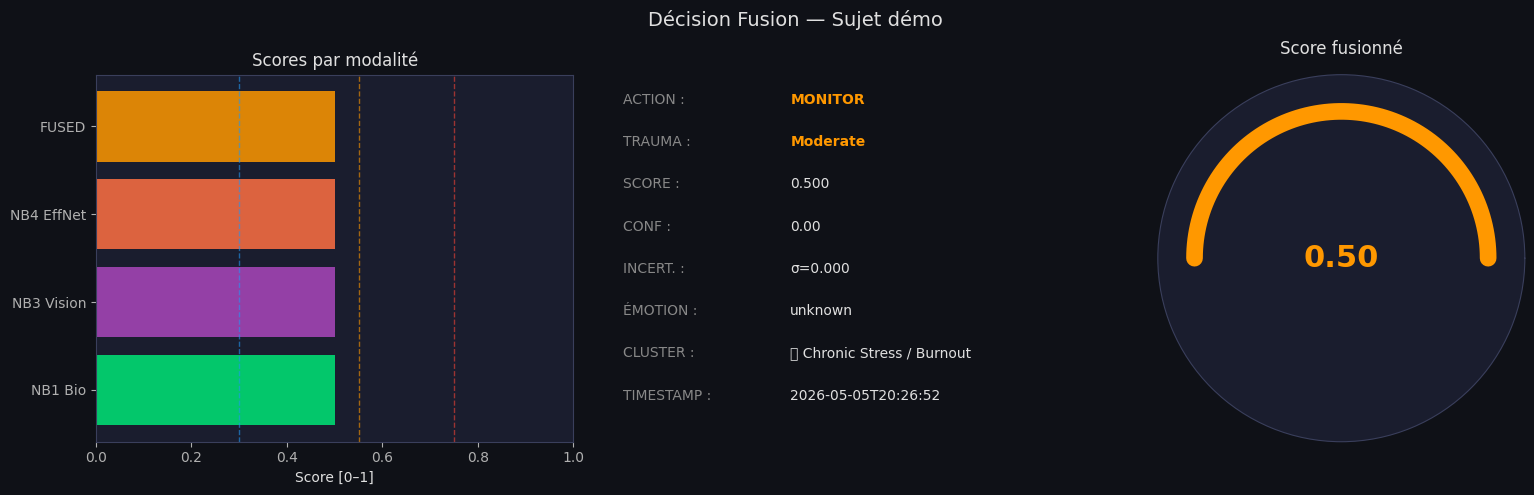

✅ Graphique sauvegardé : /kaggle/working/fusion_decision.png


In [11]:
def plot_decision(result: dict, title: str = 'Fusion Decision'):
    """Graphique radar + barre de score pour une décision de fusion."""
    fig = plt.figure(figsize=(16, 5), facecolor=DARK)
    fig.suptitle(title, color='#e0e0e0', fontsize=14)

    colors_trauma = {'Low':'#2196F3','Moderate':'#FF9800','High':'#F44336','Crisis':'#9C27B0'}
    col = colors_trauma.get(result['trauma_level'], '#aaa')

    # ── Panneau 1 : Score global ──────────────────────────────────────────────
    ax1 = fig.add_subplot(1,3,1)
    ax1.barh(['NB1 Bio','NB3 Vision','NB4 EffNet','FUSED'],
             [result['scores']['nb1'],result['scores']['nb3'],
              result['scores']['nb4'],result['fused_score']],
             color=['#00e676','#ab47bc','#ff7043',col], alpha=0.85)
    for thresh,tcol in zip([.30,.55,.75],['#2196F3','#FF9800','#F44336']):
        ax1.axvline(thresh,ls='--',lw=1,color=tcol,alpha=0.6)
    ax1.set_xlim(0,1)
    ax1.set_title('Scores par modalité', color='#e0e0e0')
    ax1.set_xlabel('Score [0–1]')

    # ── Panneau 2 : Décision textuelle ───────────────────────────────────────
    ax2 = fig.add_subplot(1,3,2)
    ax2.axis('off')
    c = result['clinical_cluster']
    lines = [
        ('ACTION',    result['action']),
        ('TRAUMA',    result['trauma_level']),
        ('SCORE',     f"{result['fused_score']:.3f}"),
        ('CONF',      f"{result['global_confidence']:.2f}"),
        ('INCERT.',   f"σ={result['uncertainty']:.3f}"),
        ('ÉMOTION',   result['emotion']),
        ('CLUSTER',   c['cluster_label'][:28]),
        ('TIMESTAMP', result['timestamp'][:19]),
    ]
    for i,(k,v) in enumerate(lines):
        ax2.text(0.05, 0.95-i*0.115, f'{k} :', color='#888', fontsize=10,
                 transform=ax2.transAxes, va='top')
        ax2.text(0.40, 0.95-i*0.115, v, color=col if i<2 else '#e0e0e0',
                 fontsize=10, fontweight='bold' if i<2 else 'normal',
                 transform=ax2.transAxes, va='top')

    # ── Panneau 3 : Jauge circulaire ─────────────────────────────────────────
    ax3 = fig.add_subplot(1,3,3, polar=True)
    score = result['fused_score']
    theta = np.linspace(0, 2*np.pi*score, 100)
    ax3.plot(theta, np.ones_like(theta)*0.8, color=col, lw=12, solid_capstyle='round')
    ax3.set_ylim(0,1); ax3.set_yticks([]); ax3.set_xticks([])
    ax3.set_facecolor(SURF)
    ax3.text(0, 0, f'{score:.2f}', ha='center', va='center',
             fontsize=22, fontweight='bold', color=col)
    ax3.set_title('Score fusionné', color='#e0e0e0', pad=15)

    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/fusion_decision.png', dpi=150, bbox_inches='tight', facecolor=DARK)
    plt.show()
    print(f'✅ Graphique sauvegardé : {MODEL_DIR}/fusion_decision.png')

# Affiche la décision de démo
plot_decision(result_demo, title=f"Décision Fusion — Sujet démo")


## Cellule 12 — Boucle temps réel (caméra)

In [12]:
def run_realtime(camera_id: int = 0, window_sec: float = 5.0, max_windows: int = 10):
    """
    Boucle temps réel : capture caméra → prédiction → affichage overlay.
    RR biométrique simulé (à remplacer par lecture wearable BLE/USB).
    Appuyer Q pour quitter.
    """
    try:
        import cv2 as _cv2
    except ImportError:
        print('OpenCV non disponible — installer avec : pip install opencv-python')
        return

    cap = _cv2.VideoCapture(camera_id)
    if not cap.isOpened():
        print(f'Impossible d\'ouvrir la caméra {camera_id}')
        return

    fps_cam    = cap.get(_cv2.CAP_PROP_FPS) or 30.0
    frame_win  = int(fps_cam * window_sec)
    buf_frames = []
    n_windows  = 0
    last_result= None

    COLORS = {'Low':(0,200,0),'Moderate':(0,170,255),'High':(0,60,255),'Crisis':(0,0,200)}

    print(f'Caméra {camera_id} ouverte. Fenêtre {window_sec}s ({frame_win} frames). Appuyer Q pour quitter.')

    while max_windows is None or n_windows < max_windows:
        ret, frame = cap.read()
        if not ret: break

        buf_frames.append(frame)

        # Overlay résultat précédent
        if last_result:
            r = last_result
            col = COLORS.get(r['trauma_level'], (200,200,200))
            overlay = frame.copy()
            _cv2.rectangle(overlay,(10,10),(480,130),(15,15,35),-1)
            _cv2.addWeighted(overlay,.65,frame,.35,0,frame)
            _cv2.putText(frame,f"{r['action']}  [{r['trauma_level']}]",
                         (20,45),_cv2.FONT_HERSHEY_DUPLEX,.9,col,2)
            _cv2.putText(frame,f"Score:{r['fused_score']:.3f}  Conf:{r['global_confidence']:.2f}",
                         (20,80),_cv2.FONT_HERSHEY_DUPLEX,.6,(210,210,210),1)
            _cv2.putText(frame,f"Cluster: {r['clinical_cluster']['cluster_label'][:30]}",
                         (20,110),_cv2.FONT_HERSHEY_DUPLEX,.5,(160,160,200),1)

        _cv2.imshow('Fusion Engine', frame)
        if _cv2.waitKey(1) & 0xFF == ord('q'):
            break

        # Fusion à chaque fenêtre complète
        if len(buf_frames) >= frame_win:
            # Prendre la frame médiane
            mid_frame = buf_frames[len(buf_frames)//2]
            img_pil   = Image.fromarray(_cv2.cvtColor(mid_frame, _cv2.COLOR_BGR2RGB))

            # RR simulé (remplacer par lecture wearable)
            rr_sim = np.random.normal(750, 40, 200)

            last_result = detect_stress_trauma(rr_ms=rr_sim, img_pil=img_pil, verbose=True)
            buf_frames  = []
            n_windows  += 1

    cap.release()
    _cv2.destroyAllWindows()
    print(f'\n✅ Terminé : {n_windows} fenêtres traitées')

# Décommenter pour lancer :
# run_realtime(camera_id=0, window_sec=5.0, max_windows=20)
print('✅ run_realtime() prête — décommenter pour utiliser avec votre caméra')


✅ run_realtime() prête — décommenter pour utiliser avec votre caméra


## Cellule 13 — Récapitulatif des modèles chargés

In [13]:
print('='*60)
print('  FUSION ENGINE — STATUT DES MODÈLES')
print('='*60)

status = [
    ('NB1 Stacking (RF+XGB+SVM)', nb1_stack is not None,
     NB1_STACK_PATH if nb1_stack else 'non trouvé'),
    ('NB1 Scaler',                nb1_scaler is not None,
     NB1_SCALER_PATH if nb1_scaler else 'non trouvé'),
    ('NB2 KMeans clustering',     nb2_kmeans is not None,
     NB2_KM_PATH if nb2_kmeans else 'fallback seuils actif'),
    ('NB3 ResNet-18 multi-task',  nb3_model is not None,
     nb3_ckpt_path if nb3_model else 'non trouvé'),
    ('NB4 EfficientNet-B2',       nb4_model is not None,
     nb4_ckpt_path if nb4_model else 'non trouvé'),
    ('NB4 YOLOv8 face detector',  nb4_yolo is not None,
     NB4_YOLO_PATH if nb4_yolo else 'non trouvé'),
]

for name, loaded, path in status:
    icon = '✅' if loaded else '⚠️ '
    print(f'  {icon}  {name:<35} {path}')

print()
n_loaded = sum(1 for _,l,_ in status if l)
print(f'  {n_loaded}/{len(status)} composants chargés')
print()
print('  Poids de fusion :')
for k,v in WEIGHTS.items():
    print(f'    {k} : {v:.0%}')
print()
print('  Usage :')
print('    result = detect_stress_trauma(rr_ms=rr_array, image_path="face.jpg")')
print('    result = detect_stress_trauma(rr_ms=rr_array, img_pil=pil_image)')
print('='*60)


  FUSION ENGINE — STATUT DES MODÈLES
  ⚠️   NB1 Stacking (RF+XGB+SVM)           non trouvé
  ⚠️   NB1 Scaler                          non trouvé
  ⚠️   NB2 KMeans clustering               fallback seuils actif
  ⚠️   NB3 ResNet-18 multi-task            non trouvé
  ⚠️   NB4 EfficientNet-B2                 non trouvé
  ⚠️   NB4 YOLOv8 face detector            non trouvé

  0/6 composants chargés

  Poids de fusion :
    nb1 : 45%
    nb4 : 35%
    nb3 : 20%

  Usage :
    result = detect_stress_trauma(rr_ms=rr_array, image_path="face.jpg")
    result = detect_stress_trauma(rr_ms=rr_array, img_pil=pil_image)
